In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
I am using a dataset of fraud detection data from Kaggle which has 284,807 lines. 

In [2]:
df = pd.read_csv("creditcard.csv")
df.groupby(["Class"]).size()
df.loc[25:35,"Class"]
df[df["Class"]==1].index
print(df.isnull().sum().max())
print("Entire table",df.shape)
print("Fraud rows:",df[df["Class"]==1].shape)

0
Entire table (284807, 31)
Fraud rows: (492, 31)


Missing values: 0
Fraud Ratio: 0.1727%


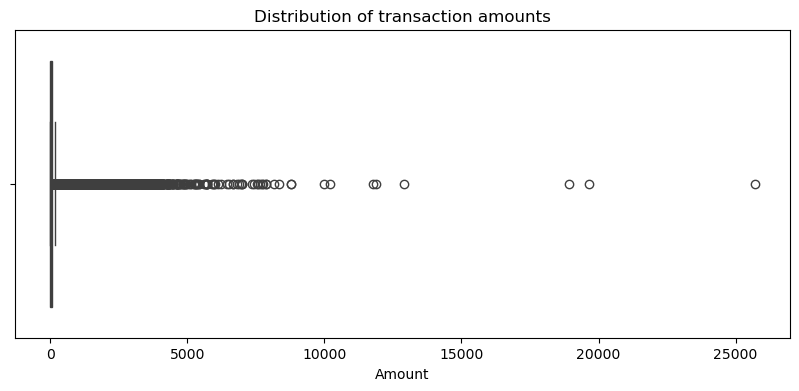

In [3]:
print(f"Missing values: {df.isnull().sum().max()}")

# Check the skew of the Target
print(f"Fraud Ratio: {df['Class'].value_counts(normalize=True)[1]:.4%}")


plt.figure(figsize=(10,4))
sns.boxplot(x=df['Amount'])
plt.title('Distribution of transaction amounts')
plt.show()

Accuracy is not useful here

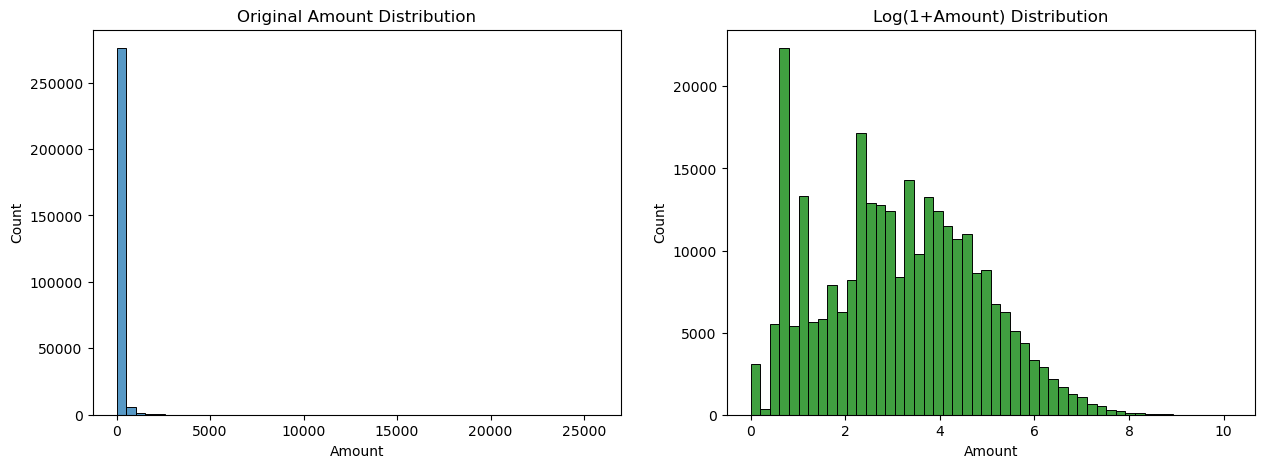

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Amount'], bins=50, ax=ax[0])
ax[0].set_title("Original Amount Distribution")

sns.histplot(np.log1p(df['Amount']), bins=50, ax=ax[1], color='green')
ax[1].set_title("Log(1+Amount) Distribution")

plt.show()

The outliers in Amount may cause early splits in the decision tree. I'll use log(amount+1) to address the distribution.

Because the dataset is too large to be able to manually build a decision tree without optimised sklearn, I'll do a random sample of 5000 rows of non fraud data and keep all the fraud one rows to simplify search of the "best split" in the decision tree.

<span style="color:red; font-weight:bold;">TODO: 
- fix the ratio
- Class imbalance</span>

In [16]:
# change amounts to log 
df = df.copy()
df["LogAmount"] = np.log1p(df["Amount"])

# separate into fraud vs non fraud dataframes
fraud_df = df[df['Class'] == 1]
non_fraud_df = df[df['Class'] == 0]

non_fraud_sample = non_fraud_df.sample(n=5000, random_state=42).reset_index(drop=True)

# put it back together and shuffle
final_df = pd.concat([fraud_df, non_fraud_sample]).sample(frac=1, random_state=42)
print("Final df:", final_df.shape)
final_df["Amount"].max()
final_df["LogAmount"].mean()

Final df: (5492, 32)


3.0975059719619567

# Entropy calculation
### Shannon Entropy
$$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

### Information Gain
$$IG(S, A) = H(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

### Gini impurity
$$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$$

In [6]:
import numpy as np

def calculate_entropy(y):
    """
    Calculates the Shannon Entropy of a label array.
    y: numpy array or pandas series
    """
    # count the values
    counts = np.bincount(y)
    
    probabilities = counts / len(y)

    # shannon formula
    entropy = -np.sum([p * np.log2(p) for p in probabilities if p > 0])
    
    return entropy


Since we don't have categorical features, we do a binary split by choosing a threshold.

In [7]:
def information_gain(parent_y, left_y, right_y):
    """
    entropy of before - entropy after split
    parent_y: the 'Class' values before the split
    left_y: the 'Class' values in the left branch (e.g., Amount <= 100)
    right_y: the 'Class' values in the right branch (e.g., Amount > 100)
    """
    # entropy of the parent (root node)
    parent_entropy = calculate_entropy(parent_y)

    n_total = len(parent_y)
    n_left = len(left_y)
    n_right = len(right_y)
    
    # if a split results in an empty group, the gain is 0
    if n_left == 0 or n_right == 0:
        return 0
    
    # (freq of one category/total * Entropy_left) + (frequency of second category/total * Entropy_right)
    expected_entropy = (n_left / n_total) * calculate_entropy(left_y) + \
                             (n_right / n_total) * calculate_entropy(right_y)
    
    # the difference
    return parent_entropy - expected_entropy

# Sanity check

In [8]:
parent_entropy = calculate_entropy(final_df['Class'].values)
print(f"Parent Entropy: {parent_entropy:.4f}")

Parent Entropy: 0.4351


In [15]:
X_manual = final_df.drop('Class', axis=1)
y_manual = final_df['Class'].values

def find_root_split(X, y):
    best_overall_gain = -1
    best_feat = None
    best_thresh = None
    
    features_to_check = X.columns 

    for feature in features_to_check:
        # Find potential thresholds (using 20-tile steps for speed)
        thresholds = np.percentile(X[feature], np.linspace(0, 100, 20))
        
        for thresh in thresholds:
            # split by theshold 
            left_mask = X[feature] <= thresh
            right_mask = X[feature] > thresh
            
            # labels
            left_y = y[left_mask]
            right_y = y[right_mask]
            
            # find the difference 
            gain = information_gain(y, left_y, right_y)
            
            # update the best feature and its threshold
            if gain > best_overall_gain:
                best_overall_gain = gain
                best_feat = feature
                best_thresh = thresh
                
    return best_feat, best_thresh, best_overall_gain


root_feature, root_threshold, root_gain = find_root_split(X_manual, y_manual)

print(f"--- THE ROOT NODE ---")
print(f"Split on: {root_feature}")
print(f"Threshold: {root_threshold:.4f}")
print(f"Information Gain: {root_gain:.4f}")

--- THE ROOT NODE ---
Split on: V14
Threshold: -1.9512
Information Gain: 0.2498


In [10]:
# Create the 'Left' and 'Right' datasets
left_mask = X_manual[root_feature] <= root_threshold
right_mask = X_manual[root_feature] > root_threshold

X_left, y_left = X_manual[left_mask], y_manual[left_mask]
X_right, y_right = X_manual[right_mask], y_manual[right_mask]

print(f"Left child size: {len(y_left)}")
print(f"Right child size: {len(y_right)}")

Left child size: 579
Right child size: 4913


In [11]:
root_feature, root_threshold, root_gain = find_root_split(X_left, y_left)
print(f"Split on: {root_feature}")
print(f"Threshold: {root_threshold:.4f}")
print(f"Information Gain: {root_gain:.4f}")

Split on: V12
Threshold: -1.9606
Information Gain: 0.5543


In [12]:
root_feature, root_threshold, root_gain = find_root_split(X_right, y_right)
print(f"Split on: {root_feature}")
print(f"Threshold: {root_threshold:.4f}")
print(f"Information Gain: {root_gain:.4f}")

Split on: V4
Threshold: 1.4476
Information Gain: 0.0116


# Build a tree recursively

In [13]:
def build_tree_recursive(X, y, depth=0, max_depth=3, min_samples=20):
    # Stop if all labels are the same (Entropy = 0)
    if len(np.unique(y)) == 1:
        return {'type': 'leaf', 'class': y[0], 'samples': len(y)}
    
    # Stop if we hit max depth or data is too small
    if depth >= max_depth or len(y) < min_samples:
        # Return the majority class (0 or 1)
        majority_class = np.bincount(y).argmax()
        return {'type': 'leaf', 'class': majority_class, 'samples': len(y)}

    feat, thresh, gain = find_root_split(X, y)
    
    # If no gain is possible, stop and make a leaf
    if gain <= 0:
        majority_class = np.bincount(y).argmax()
        return {'type': 'leaf', 'class': majority_class, 'samples': len(y)}

    # do the partition
    left_mask = X[feat] <= thresh
    right_mask = X[feat] > thresh
    
    return {
        'type': 'node',
        'feature': feat,
        'threshold': thresh,
        'gain': gain,
        'samples': len(y),
        'left': build_tree_recursive(X[left_mask], y[left_mask], depth + 1, max_depth, min_samples),
        'right': build_tree_recursive(X[right_mask], y[right_mask], depth + 1, max_depth, min_samples)
    }



In [29]:
test_frac = 0.25
n_test = int(len(final_df) * test_frac)

test_df = final_df.iloc[:n_test]
train_df = final_df.iloc[n_test:]

X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"].astype(int).values

X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"].astype(int).values


print("Train fraud rate:", y_train.mean(), "Test fraud rate:", y_test.mean())



my_tree = build_tree_recursive(X_manual, y_manual, max_depth=3)

Train fraud rate: 0.08424374848264142 Test fraud rate: 0.1056081573197378


In [30]:
my_tree

{'type': 'node',
 'feature': 'V14',
 'threshold': -1.95123082498425,
 'gain': 0.24976762358347318,
 'samples': 5492,
 'left': {'type': 'node',
  'feature': 'V12',
  'threshold': -1.9605943929395193,
  'gain': 0.5542936413343822,
  'samples': 579,
  'left': {'type': 'node',
   'feature': 'V7',
   'threshold': 0.12016870946236986,
   'gain': 0.04605071277826521,
   'samples': 396,
   'left': {'type': 'leaf', 'class': 1, 'samples': 375},
   'right': {'type': 'leaf', 'class': 1, 'samples': 21}},
  'right': {'type': 'node',
   'feature': 'V4',
   'threshold': 1.927362590407978,
   'gain': 0.22028127533362762,
   'samples': 183,
   'left': {'type': 'leaf', 'class': 0, 'samples': 144},
   'right': {'type': 'leaf', 'class': 1, 'samples': 39}}},
 'right': {'type': 'node',
  'feature': 'V4',
  'threshold': 1.4476307138449718,
  'gain': 0.011594891582440342,
  'samples': 4913,
  'left': {'type': 'node',
   'feature': 'V14',
   'threshold': -0.4719432204106323,
   'gain': 0.004009597788035078,
   

In [32]:
def predict_one(x_row, tree):
    if tree['type'] == 'leaf':
        return tree['class']
    
    if x_row[tree['feature']] <= tree['threshold']:
        return predict_one(x_row, tree['left'])
    else:
        return predict_one(x_row, tree['right'])

def predict(X, tree):
    return np.array([predict_one(row, tree) for _, row in X.iterrows()])

y_pred = predict(X_test, my_tree)
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


[[1223    5]
 [  19  126]]
              precision    recall  f1-score   support

           0      0.985     0.996     0.990      1228
           1      0.962     0.869     0.913       145

    accuracy                          0.983      1373
   macro avg      0.973     0.932     0.952      1373
weighted avg      0.982     0.983     0.982      1373

